# Solemne IA — Optimización (CINF105)
## Distribución de combustibles con Tabu Search

**Notebook de cálculo.** Aquí se *ejecuta el código* que resuelve y verifica la
prueba. Las preguntas escritas (formulación, interpretación) van en el PDF; este
notebook produce los **números, tablas y figuras** que respaldan esas respuestas.

> **Importante:** todos los datos provienen del enunciado. No se inventa ningún
> valor. El modelo y la metaheurística están en `modelo.py` y `tabu.py`.

**¿Por qué Tabu Search y no AMPL?** El problema es un *ruteo de vehículos con
ventanas de tiempo* (VRPTW) más asignación de compartimentos: combinatorio y
NP-difícil en general. Tabu Search (Glover, 1986) es una metaheurística clásica
para VRP: explora soluciones vecinas y usa una *memoria* (lista tabú) para no
volver atrás y escapar de óptimos locales. Como el caso es pequeño, además
comprobamos con **fuerza bruta** que Tabu Search llega al óptimo global.

## 0. Datos del problema (escenario s = 1)

In [1]:
from modelo import *
print("Estaciones y demanda (R=Regular, D=Diesel):")
for j in ESTACIONES:
    a, b = VENTANA[j]
    print(f"  Est {j}: R={DEMANDA[j]['R']:>5} L  D={DEMANDA[j]['D']:>5} L  "
          f"ventana [{a//60:02d}:{a%60:02d}-{b//60:02d}:{b%60:02d}]")
print("\nCamiones:")
for k, c in CAMIONES.items():
    print(f"  {k}: C0={c['C0']} L  C1={c['C1']} L  fijo=${c['fijo']}  "
          f"salida {c['salida']//60:02d}:{c['salida']%60:02d}")
print(f"\nCosto distancia=${COSTO_KM}/km | Penalizacion shortage=${PENAL_SHORTAGE}/L | "
      f"Servicio={SERVICIO} min | Delta estabilidad={DELTA}")

Estaciones y demanda (R=Regular, D=Diesel):
  Est 1: R= 3000 L  D= 2000 L  ventana [06:00-10:00]
  Est 2: R= 4000 L  D= 1500 L  ventana [07:00-12:00]
  Est 3: R= 2500 L  D= 3000 L  ventana [08:00-14:00]
  Est 4: R= 1000 L  D= 2500 L  ventana [06:00-11:00]

Camiones:
  T1: C0=8000 L  C1=7000 L  fijo=$500  salida 05:00
  T2: C0=6000 L  C1=9000 L  fijo=$400  salida 05:30

Costo distancia=$2/km | Penalizacion shortage=$10/L | Servicio=30 min | Delta estabilidad=0.3


## 1. Modelo de evaluación (función objetivo y restricciones)

Cada solución asigna estaciones a camiones, define el orden de visita y qué
combustible va en cada compartimento. La función `evaluar` calcula el **costo
total** = costo de distancia + costos fijos + penalización por litros no
entregados, y revisa la factibilidad:

- **Capacidad**: cada compartimento ≥ demanda asignada.
- **Estabilidad** (Δ=0.30): `|fill_C0 − fill_C1| ≤ 0.30` en cada instante.
- **Ventanas de tiempo**: llegar a la estación dentro de su horario.
- **Cobertura**: cada estación se visita exactamente una vez.

In [2]:
# Ejemplo: evaluar una solucion cualquiera
ejemplo = {"T1": {"ruta": [1, 2], "comp": {"C0":"R","C1":"D"}},
           "T2": {"ruta": [3, 4], "comp": {"C0":"R","C1":"D"}}}
ev = evaluar(ejemplo)
print(ev)

{'costo': 1200, 'dist_km': 150, 'costo_distancia': 300, 'costo_fijo': 900, 'shortage': 0, 'factible': False, 'cobertura_ok': True, 'detalles': {'T1': {'dist': 65, 'estabilidad_ok': False, 'ventanas_ok': True, 'shortage': 0}, 'T2': {'dist': 85, 'estabilidad_ok': True, 'ventanas_ok': True, 'shortage': 0}}}


## 2. Pregunta 1 / 3c — Ruteo óptimo con **Tabu Search**

Resolvemos el ruteo *desde cero*. Tabu Search parte de una solución inicial,
explora todos los vecinos (mover/intercambiar estaciones, reordenar rutas,
cambiar compartimentos) y se mueve al mejor, guardando los movimientos recientes
en la lista tabú.

In [3]:
from tabu import tabu_search, solucion_inicial, vecinos
mejor, ev, hist = tabu_search(iteraciones=60, tenencia=7)
print("Solucion optima encontrada por Tabu Search:")
for k in ("T1","T2"):
    r = mejor[k]["ruta"]
    if r:
        print(f"  {k}: D->{'->'.join(map(str,r))}->D | comp {mejor[k]['comp']} "
              f"| {distancia_ruta(r)} km")
    else:
        print(f"  {k}: NO se usa")
print(f"\nDistancia total = {ev['dist_km']} km")
print(f"Costo distancia  = ${ev['costo_distancia']}")
print(f"Costo fijo       = ${ev['costo_fijo']}")
print(f"Shortage         = {ev['shortage']} L")
print(f"COSTO TOTAL      = ${ev['costo']}  | factible = {ev['factible']}")

Solucion optima encontrada por Tabu Search:
  T1: D->1->2->4->D | comp {'C0': 'R', 'C1': 'D'} | 85 km
  T2: D->3->D | comp {'C0': 'R', 'C1': 'D'} | 30 km

Distancia total = 115 km
Costo distancia  = $230
Costo fijo       = $900
Shortage         = 0 L
COSTO TOTAL      = $1130  | factible = True


### 2.1 Verificación: ¿Tabu Search alcanzó el óptimo global? (fuerza bruta)

In [4]:
bf_sol, bf_ev, n_fact = optimo_fuerza_bruta()
print(f"Soluciones factibles enumeradas: {n_fact}")
print(f"Costo optimo global (fuerza bruta): ${bf_ev['costo']} ({bf_ev['dist_km']} km)")
print(f"Costo Tabu Search:                  ${ev['costo']} ({ev['dist_km']} km)")
print(f">>> Tabu Search == optimo global: {ev['costo'] == bf_ev['costo']}")

Soluciones factibles enumeradas: 54
Costo optimo global (fuerza bruta): $1130 (115 km)
Costo Tabu Search:                  $1130 (115 km)
>>> Tabu Search == optimo global: True


### 2.2 Estabilidad de la solución óptima (Δ ≤ 0.30 en todo instante)

In [5]:
for k in ("T1","T2"):
    if mejor[k]["ruta"]:
        print(f"{k}  ruta {mejor[k]['ruta']}  comp {mejor[k]['comp']}")
        for etq,a,b in perfil_fill_ratios(k, mejor[k]['ruta'], mejor[k]['comp']):
            ok = "OK" if abs(a-b)<=DELTA+1e-9 else "VIOLA"
            print(f"   {etq:18s} C0={a*100:5.1f}%  C1={b*100:5.1f}%  |dif|={abs(a-b)*100:4.1f}%  {ok}")

T1  ruta [1, 2, 4]  comp {'C0': 'R', 'C1': 'D'}
   Salida deposito    C0=100.0%  C1= 85.7%  |dif|=14.3%  OK
   Tras estacion 1    C0= 62.5%  C1= 57.1%  |dif|= 5.4%  OK
   Tras estacion 2    C0= 12.5%  C1= 35.7%  |dif|=23.2%  OK
   Tras estacion 4    C0=  0.0%  C1=  0.0%  |dif|= 0.0%  OK
T2  ruta [3]  comp {'C0': 'R', 'C1': 'D'}
   Salida deposito    C0= 41.7%  C1= 33.3%  |dif|= 8.3%  OK
   Tras estacion 3    C0=  0.0%  C1=  0.0%  |dif|= 0.0%  OK


### 2.3 Figuras: convergencia y rutas

Figuras generadas: ['convergencia.png', 'rutas_operador.png', 'rutas_optimo.png', 'estabilidad_t2.png', 'gantt.png']


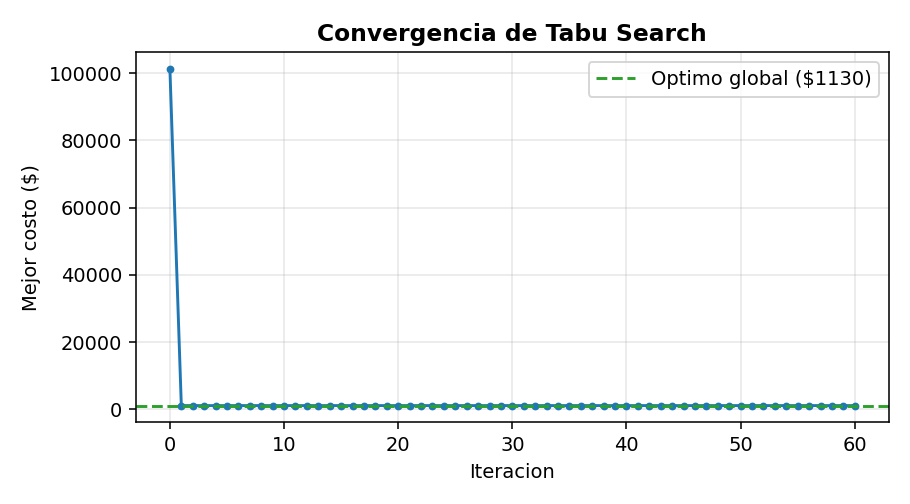

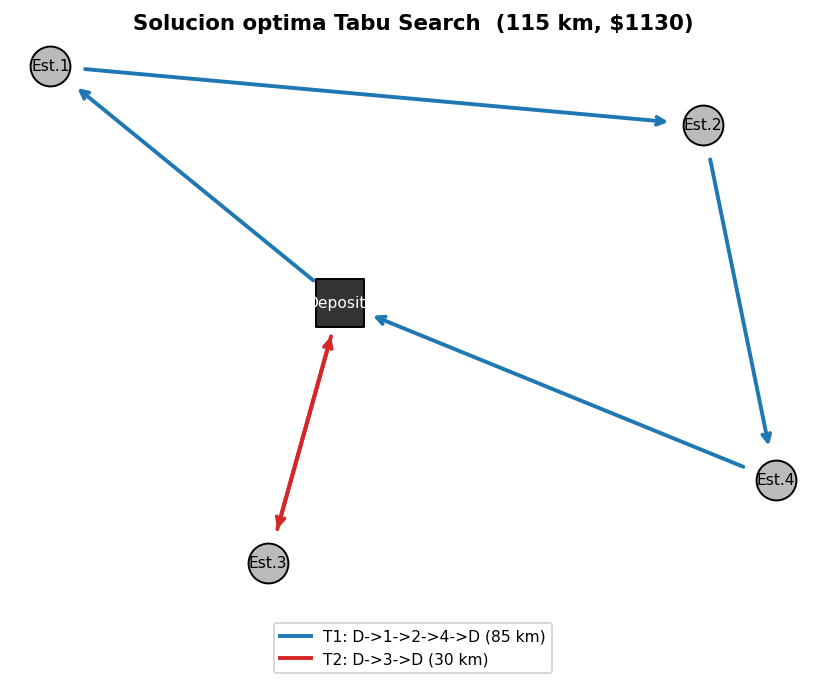

In [6]:
from IPython.display import Image, display
import figuras  # genera/actualiza los PNG
display(Image('figuras/convergencia.png'))
display(Image('figuras/rutas_optimo.png'))

## 3. Pregunta 3 — Verificación de la solución del operador

El operador propone: **T1**: D→1→3→D (C0=Regular, C1=Diésel) y
**T2**: D→2→4→D (C0=Diésel, C1=Regular), declarando *costo de distancia = \$260*
y *shortage = 0*.

In [7]:
operador = {"T1": {"ruta":[1,3], "comp":{"C0":"R","C1":"D"}},
            "T2": {"ruta":[2,4], "comp":{"C0":"D","C1":"R"}}}

print("(a1) CAPACIDAD")
for k in ("T1","T2"):
    for c in ("C0","C1"):
        fuel = operador[k]["comp"][c]
        req = sum(DEMANDA[j][fuel] for j in operador[k]["ruta"])
        cap = CAMIONES[k][c]
        print(f"  {k} {c}={fuel}: requiere {req} L / cap {cap} L -> "
              f"{'OK' if req<=cap else 'EXCEDE'} (fill {req/cap*100:.1f}%)")

(a1) CAPACIDAD
  T1 C0=R: requiere 5500 L / cap 8000 L -> OK (fill 68.8%)
  T1 C1=D: requiere 5000 L / cap 7000 L -> OK (fill 71.4%)
  T2 C0=D: requiere 4000 L / cap 6000 L -> OK (fill 66.7%)
  T2 C1=R: requiere 5000 L / cap 9000 L -> OK (fill 55.6%)


In [8]:
print("(a2) ESTABILIDAD Delta=0.30  (cargando para cubrir la demanda)")
for k in ("T1","T2"):
    print(f"{k}  ruta {operador[k]['ruta']}")
    for etq,a,b in perfil_fill_ratios(k, operador[k]['ruta'], operador[k]['comp']):
        ok = "OK" if abs(a-b)<=DELTA+1e-9 else ">>> VIOLA"
        print(f"   {etq:18s} C0={a*100:5.1f}%  C1={b*100:5.1f}%  |dif|={abs(a-b)*100:4.1f}%  {ok}")

(a2) ESTABILIDAD Delta=0.30  (cargando para cubrir la demanda)
T1  ruta [1, 3]
   Salida deposito    C0= 68.8%  C1= 71.4%  |dif|= 2.7%  OK
   Tras estacion 1    C0= 31.2%  C1= 42.9%  |dif|=11.6%  OK
   Tras estacion 3    C0=  0.0%  C1=  0.0%  |dif|= 0.0%  OK
T2  ruta [2, 4]
   Salida deposito    C0= 66.7%  C1= 55.6%  |dif|=11.1%  OK
   Tras estacion 2    C0= 41.7%  C1= 11.1%  |dif|=30.6%  >>> VIOLA
   Tras estacion 4    C0=  0.0%  C1=  0.0%  |dif|= 0.0%  OK


(a2-fix) Si T2 invierte su ruta a D->4->2->D:
   Salida deposito    C0= 66.7%  C1= 55.6%  |dif|=11.1%  OK
   Tras estacion 4    C0= 25.0%  C1= 44.4%  |dif|=19.4%  OK
   Tras estacion 2    C0=  0.0%  C1=  0.0%  |dif|= 0.0%  OK


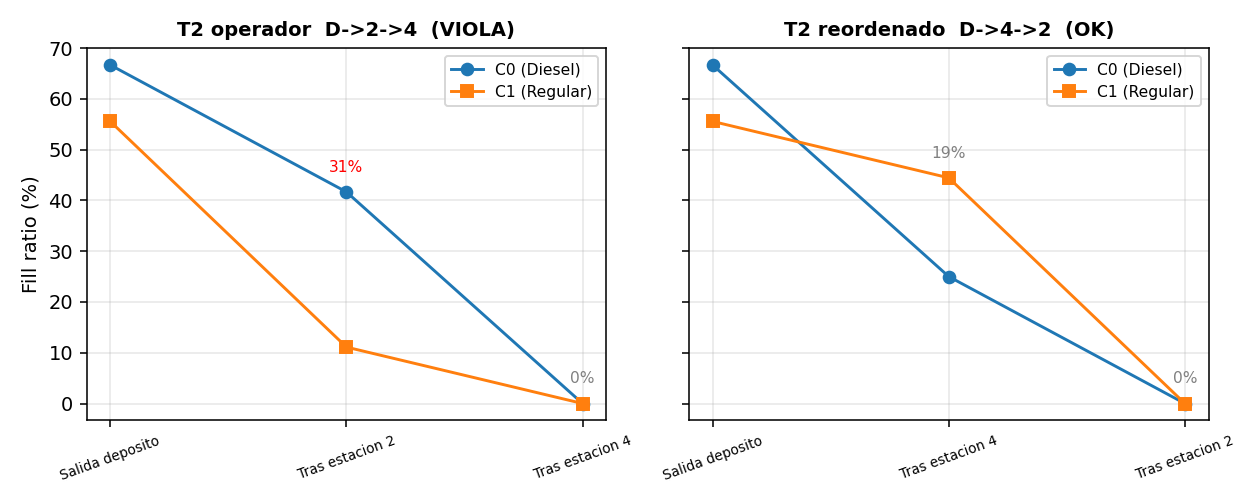

In [9]:
print("(a2-fix) Si T2 invierte su ruta a D->4->2->D:")
for etq,a,b in perfil_fill_ratios("T2", [4,2], {"C0":"D","C1":"R"}):
    ok = "OK" if abs(a-b)<=DELTA+1e-9 else ">>> VIOLA"
    print(f"   {etq:18s} C0={a*100:5.1f}%  C1={b*100:5.1f}%  |dif|={abs(a-b)*100:4.1f}%  {ok}")
display(Image('figuras/estabilidad_t2.png'))

In [10]:
print("(a3) VENTANAS DE TIEMPO (velocidad 60 km/h, servicio 30 min)")
for k in ("T1","T2"):
    print(f"{k} sale {CAMIONES[k]['salida']//60:02d}:{CAMIONES[k]['salida']%60:02d}")
    for j,lleg,ini in tiempos_llegada(k, operador[k]['ruta']):
        a,b = VENTANA[j]
        est = "DENTRO" if a<=lleg<=b else ("TARDE" if lleg>b else "ANTES (espera hasta a_j)")
        print(f"   Est {j}: llega {lleg//60:02d}:{int(lleg%60):02d}  "
              f"ventana [{a//60:02d}:{a%60:02d}-{b//60:02d}:{b%60:02d}]  {est}")

(a3) VENTANAS DE TIEMPO (velocidad 60 km/h, servicio 30 min)
T1 sale 05:00
   Est 1: llega 05:20  ventana [06:00-10:00]  ANTES (espera hasta a_j)
   Est 3: llega 06:55  ventana [08:00-14:00]  ANTES (espera hasta a_j)
T2 sale 05:30
   Est 2: llega 06:05  ventana [07:00-12:00]  ANTES (espera hasta a_j)
   Est 4: llega 07:45  ventana [06:00-11:00]  DENTRO


In [11]:
print("(b) VERIFICACION DEL COSTO DECLARADO")
ev_op = evaluar(operador)
print(f"  Distancia T1 {operador['T1']['ruta']} = {distancia_ruta(operador['T1']['ruta'])} km")
print(f"  Distancia T2 {operador['T2']['ruta']} = {distancia_ruta(operador['T2']['ruta'])} km")
print(f"  Distancia total = {ev_op['dist_km']} km -> costo distancia REAL = ${ev_op['costo_distancia']}")
print(f"  Operador declaro $260  ->  {'CORRECTO' if ev_op['costo_distancia']==260 else 'ERROR (real $300)'}")
print(f"  Costo fijo (ambos camiones) = ${ev_op['costo_fijo']}  (el operador lo omitio)")
print(f"  COSTO TOTAL REAL = ${ev_op['costo']}")

(b) VERIFICACION DEL COSTO DECLARADO
  Distancia T1 [1, 3] = 60 km
  Distancia T2 [2, 4] = 90 km
  Distancia total = 150 km -> costo distancia REAL = $300
  Operador declaro $260  ->  ERROR (real $300)
  Costo fijo (ambos camiones) = $900  (el operador lo omitio)
  COSTO TOTAL REAL = $1200


### 3.1 Propuesta de mejora (3c)
La solución óptima de Tabu Search (**T1**: D→1→2→4→D, **T2**: D→3→D) recorre
**115 km** en vez de 150 km, es **factible** en capacidad, estabilidad y
ventanas, y baja el costo de distancia de \$300 a **\$230** (ahorro de \$70).

In [12]:
print(f"Operador (corregido): {ev_op['dist_km']} km, costo distancia ${ev_op['costo_distancia']}, total ${ev_op['costo']}")
print(f"Optimo Tabu Search:   {ev['dist_km']} km, costo distancia ${ev['costo_distancia']}, total ${ev['costo']}")
print(f"Ahorro en distancia:  ${ev_op['costo_distancia']-ev['costo_distancia']}")

Operador (corregido): 150 km, costo distancia $300, total $1200
Optimo Tabu Search:   115 km, costo distancia $230, total $1130
Ahorro en distancia:  $70


## 4. Pregunta 2 — Tiempos de carga y scheduling (makespan)

Volúmenes fijos: **T1** carga 5000 L Regular (C0) y 5000 L Diésel (C1);
**T2** carga 4000 L Diésel (C0) y 3500 L Regular (C1).
Tiempo = litros / tasa + 5 min de limpieza. Tasas: Regular 500 L/min,
Diésel 400 L/min. Una sola bahía por combustible.

(a) Tiempos de carga (incluye 5 min de limpieza):
   T1_C0 (R 5000 L): 5000/500 + 5 = 15.0 min
   T1_C1 (D 5000 L): 5000/400 + 5 = 17.5 min
   T2_C0 (D 4000 L): 4000/400 + 5 = 15.0 min
   T2_C1 (R 3500 L): 3500/500 + 5 = 12.0 min

(c) Programacion optima:
   T1_C0: inicia 0.0 min, termina 15.0 min
   T1_C1: inicia 15.0 min, termina 32.5 min
   T2_C0: inicia 0.0 min, termina 15.0 min
   T2_C1: inicia 15.0 min, termina 27.0 min

   Camion listo: T1=32.5 min | T2=27.0 min
   MAKESPAN = 32.5 min  (cuello de botella = bahia Diesel: 15 + 17.5)


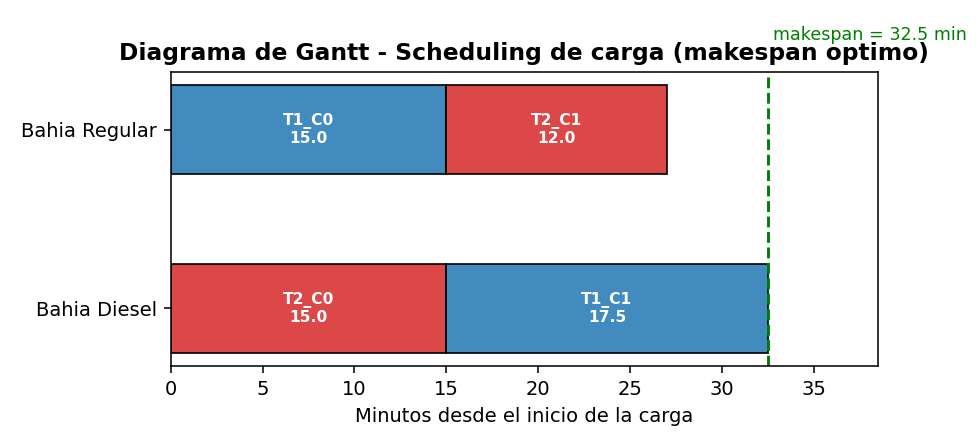

In [13]:
dur, ini, fin, listo, mk = scheduling_makespan()
print("(a) Tiempos de carga (incluye 5 min de limpieza):")
for op_id,k,c,fuel,lit in OPERACIONES_CARGA:
    print(f"   {op_id} ({fuel} {lit} L): {lit}/{TASA[fuel]} + 5 = {dur[op_id]:.1f} min")
print("\n(c) Programacion optima:")
for op_id in ["T1_C0","T1_C1","T2_C0","T2_C1"]:
    print(f"   {op_id}: inicia {ini[op_id]:.1f} min, termina {fin[op_id]:.1f} min")
print(f"\n   Camion listo: T1={listo['T1']:.1f} min | T2={listo['T2']:.1f} min")
print(f"   MAKESPAN = {mk:.1f} min  (cuello de botella = bahia Diesel: 15 + 17.5)")
display(Image('figuras/gantt.png'))

In [14]:
# Verificacion: si la carga inicia a las 04:00, ambos salen a tiempo
inicio_carga = hm(4,0)
for k in ("T1","T2"):
    listo_hhmm = inicio_carga + listo[k]
    salida = CAMIONES[k]['salida']
    print(f"{k}: listo a las {int(listo_hhmm//60):02d}:{int(listo_hhmm%60):02d}  "
          f"| debe salir {salida//60:02d}:{salida%60:02d}  -> "
          f"{'OK' if listo_hhmm<=salida else 'NO ALCANZA'}")

T1: listo a las 04:32  | debe salir 05:00  -> OK
T2: listo a las 04:27  | debe salir 05:30  -> OK


## 5. Pregunta 4 — Extensión estocástica (datos por escenario)

Tres escenarios de demanda con probabilidades 0.5 / 0.3 / 0.2. Aquí mostramos la
demanda total por escenario (la formulación de dos etapas va en el PDF).

In [15]:
tot = demanda_total_por_escenario()
print(f"{'Escenario':12s} {'Prob':>5s} {'Regular':>9s} {'Diesel':>9s} {'Total':>8s}")
for s,d in tot.items():
    print(f"{s:12s} {d['prob']:>5} {d['R']:>9} {d['D']:>9} {d['total']:>8}")
flota = sum(c['C0']+c['C1'] for c in CAMIONES.values())
print(f"\nCapacidad total de la flota: {flota} L")
# capacidad por combustible si se dedica un compartimento por camion a cada uno
cap_R = CAMIONES['T1']['C0'] + CAMIONES['T2']['C1']   # 8000 + 9000
cap_D = CAMIONES['T1']['C1'] + CAMIONES['T2']['C0']   # 7000 + 6000
print(f"Capacidad maxima Regular (T1.C0+T2.C1) = {cap_R} L")
print(f"Capacidad maxima Diesel  (T1.C1+T2.C0) = {cap_D} L")
for s,d in tot.items():
    print(f"  {s}: Regular {d['R']}<= {cap_R}? {d['R']<=cap_R} | "
          f"Diesel {d['D']}<= {cap_D}? {d['D']<=cap_D}")

Escenario     Prob   Regular    Diesel    Total
s1_Normal      0.5     10500      9000    19500
s2_Alta        0.3     14500     10300    24800
s3_Baja        0.2      7800      7700    15500

Capacidad total de la flota: 30000 L
Capacidad maxima Regular (T1.C0+T2.C1) = 17000 L
Capacidad maxima Diesel  (T1.C1+T2.C0) = 13000 L
  s1_Normal: Regular 10500<= 17000? True | Diesel 9000<= 13000? True
  s2_Alta: Regular 14500<= 17000? True | Diesel 10300<= 13000? True
  s3_Baja: Regular 7800<= 17000? True | Diesel 7700<= 13000? True


**Costo esperado (valor de referencia).** Si se mantiene el ruteo de
primera etapa, el costo esperado es
$\;\mathbb{E}[\text{costo}] = \sum_s p_s \, \text{costo}(s)$. El detalle de
primera/segunda etapa se desarrolla en el PDF.